First preparing data for training FFNN

In [1]:
import pandas as pd
import numpy as np
from model_functions.FFNN import FFNN
from sklearn.preprocessing import StandardScaler

train= pd.read_csv('claims_train.csv')
test = pd.read_csv('claims_test.csv')

#Cleaning weird values that found during cleaning
train = train[train['Exposure'] <= 1].copy()
test =test[test['Exposure']<=1].copy()

# Getting target column

y_train_np = train["ClaimNb"].to_numpy().reshape(-1, 1)
y_test_np  = test["ClaimNb"].to_numpy().reshape(-1, 1)
y_train=train['ClaimNb']
y_test=test['ClaimNb']

# Dropping correlated and useless columns
train=train.drop(columns=['IDpol', 'ClaimNb','Exposure'])
test=test.drop(columns=['IDpol', 'ClaimNb','Exposure'])

#Encoding
train_encoded=pd.get_dummies(train, columns=['VehBrand', 'VehGas', 'Region'], drop_first=True)#Encoding categorical values
area_map={'A':1,'B':2,'C':3,'D':4,'E':5,'F':6}
train_encoded['Area']=train_encoded['Area'].map(area_map)

test_encoded=pd.get_dummies(test, columns=['VehBrand', 'VehGas', 'Region'], drop_first=True)#Encoding categorical values
area_map={'A':1,'B':2,'C':3,'D':4,'E':5,'F':6}
test_encoded['Area']=test_encoded['Area'].map(area_map)

#Standarizing values
Scaler = StandardScaler()
train_encoded = Scaler.fit_transform(train_encoded)
test_encoded  = Scaler.transform(test_encoded)

X_train=train_encoded
X_test=test_encoded
X_train_np = np.asarray(train_encoded, dtype=float)
X_test_np  = np.asarray(test_encoded, dtype=float)




Time to use the self-made FFNN model. We decided it would makes sense to choose 64 neurons for first hidden layer and 32 for the second one

In [2]:

model=FFNN(input_size=38,hidden_sizes=[64,32],output_size=1, lr=0.001)
model.fit(X=X_train_np,y=y_train_np,epochs=50, batch_size=1024)
y_pred=model.predict(X=X_test_np)

from sklearn.metrics import mean_poisson_deviance
poisson_dev = mean_poisson_deviance(y_test_np, y_pred)
print(f"Poisson Deviance: {poisson_dev:.4f}")

Epoch 0, Loss=0.2752494679305963
Epoch 1, Loss=0.254361805068928
Epoch 2, Loss=0.2108815457580312
Epoch 3, Loss=0.22217566247921192
Epoch 4, Loss=0.20192683197666894
Epoch 5, Loss=0.20317135280267004
Epoch 6, Loss=0.22384872952148419
Epoch 7, Loss=0.230329287903357
Epoch 8, Loss=0.1786634926177806
Epoch 9, Loss=0.232863505336457
Epoch 10, Loss=0.21470230031131562
Epoch 11, Loss=0.2150329864873906
Epoch 12, Loss=0.2667662373541052
Epoch 13, Loss=0.19161436549463043
Epoch 14, Loss=0.2963822901553126
Epoch 15, Loss=0.2674996865583393
Epoch 16, Loss=0.2287921553988869
Epoch 17, Loss=0.24862172432314206
Epoch 18, Loss=0.2338341634068103
Epoch 19, Loss=0.23921054966312394
Epoch 20, Loss=0.22318821996099053
Epoch 21, Loss=0.21940539614636176
Epoch 22, Loss=0.24992193613226377
Epoch 23, Loss=0.19380276788895637
Epoch 24, Loss=0.18469704671320497
Epoch 25, Loss=0.18277764891020232
Epoch 26, Loss=0.15459282466653565
Epoch 27, Loss=0.19662031058608403
Epoch 28, Loss=0.23270273811868625
Epoch 29, 

In [3]:
y_pred_flat = np.array(y_pred).reshape(-1)
df=pd.DataFrame({"y_test":y_test, "y_pred":y_pred_flat})
df["bucket"] = pd.qcut(df.y_pred, q=10, labels=False)
tab_FFNN=df.groupby("bucket")["y_test"].mean()
print(tab_FFNN)

bucket
0    0.054956
1    0.052962
2    0.054374
3    0.053483
4    0.053110
5    0.054443
6    0.051415
7    0.055847
8    0.052150
9    0.054813
Name: y_test, dtype: float64


Lift of Top 10 % compared to average

In [4]:
overall_mean=y_test.mean()
lift_FFNN= tab_FFNN.iloc[-1]/ overall_mean
print(lift_FFNN)

1.0196735520415552


Now we decided to do a classification view evaluation

In [5]:
from sklearn.metrics import precision_recall_curve, average_precision_score
y_true_bin= (y_test >0).astype(int)
y_true_bin[y_true_bin >0]

precision, recall, thresholds = precision_recall_curve(y_true_bin, y_pred)
ap_FFNN = average_precision_score(y_true_bin, y_pred)

print(ap_FFNN)

0.050937773324427775


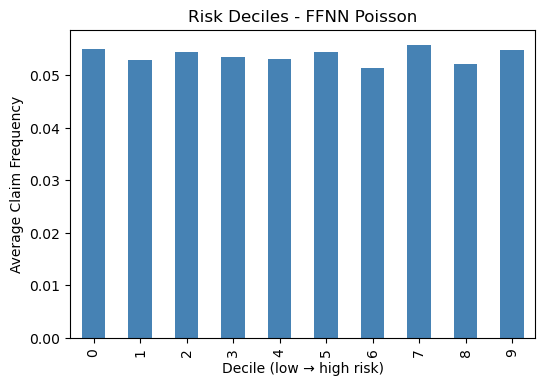

In [6]:
import matplotlib.pyplot as plt
def decile_plot(y_true, y_pred, model_name):
    df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df["decile"] = pd.qcut(df["y_pred"], 10, labels=False)

    deciles = df.groupby("decile")["y_true"].mean()

    plt.figure(figsize=(6,4))
    deciles.plot(kind="bar", color="steelblue")
    plt.title(f"Risk Deciles - {model_name}")
    plt.ylabel("Average Claim Frequency")
    plt.xlabel("Decile (low → high risk)")
    plt.show()
y_test_1d = y_test_np.reshape(-1)
decile_plot(y_test_1d, y_pred_flat, model_name= 'FFNN Poisson')

C:\Users\shere\AppData\Local\Temp\ipykernel_27392\669445038.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = df.groupby("bucket").agg(


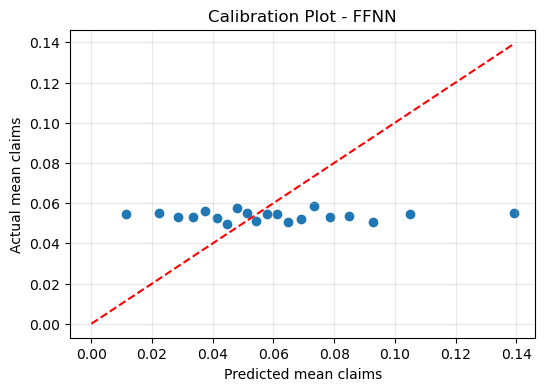

In [7]:
def calibration_plot(y_true, y_pred, model_name, bins=20):
    df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df["bucket"] = pd.qcut(df["y_pred"], bins, duplicates='drop')
    
    calib = df.groupby("bucket").agg(
        predicted=("y_pred","mean"),
        actual=("y_true","mean")
    )

    plt.figure(figsize=(6,4))
    plt.scatter(calib["predicted"], calib["actual"], label=model_name)
    max_val = max(calib["predicted"].max(), calib["actual"].max())
    plt.plot([0, max_val], [0, max_val], "r--")
    plt.xlabel("Predicted mean claims")
    plt.ylabel("Actual mean claims")
    plt.title(f"Calibration Plot - {model_name}")
    plt.grid(alpha=0.3)
    plt.show()
calibration_plot(y_test_1d, y_pred_flat, "FFNN")

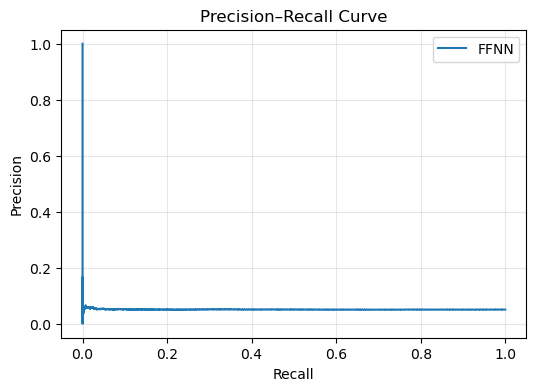

In [8]:
def pr_curve(y_true_bin, y_pred, model_name):
    precision, recall, thresholds = precision_recall_curve(y_true_bin, y_pred)

    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, label=model_name)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
pr_curve((y_test>0).astype(int), y_pred, "FFNN")

Self-made FFNN  gives quite a weak result. Worse than a decision tree which is unexpected. Now I want to check how a library FFNN would perform

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

class PoissonFFNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Softplus()
        )

    def forward(self, x):
        return self.net(x)

model = PoissonFFNN(input_dim=X_train.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.PoissonNLLLoss(log_input=False)

for epoch in range(50):
    optimizer.zero_grad()
    pred = model(torch.tensor(X_train, dtype=torch.float32))
    loss = criterion(pred.squeeze(), torch.tensor(y_train.values, dtype=torch.float32))
    loss.backward()
    optimizer.step()
    print(epoch, loss.item())
with torch.no_grad():
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_pred_FFNN = model(X_test_t).squeeze().numpy()
mpd_ffnn = mean_poisson_deviance(y_test, y_pred_FFNN)
print("Poisson Deviance (FFNN):", mpd_ffnn)

0 0.6812717318534851
1 0.5530509948730469
2 0.4386311173439026
3 0.33857226371765137
4 0.2651382088661194
5 0.22798074781894684
6 0.2242632359266281
7 0.23969291150569916
8 0.2580530345439911
9 0.26998263597488403
10 0.2729615569114685
11 0.2679896354675293
12 0.257447749376297
13 0.24412654340267181
14 0.23076973855495453
15 0.21970531344413757
16 0.21247605979442596
17 0.20956352353096008
18 0.2103569209575653
19 0.21342498064041138
20 0.21704021096229553
21 0.21973806619644165
22 0.22067125141620636
23 0.21970100700855255
24 0.2172536998987198
25 0.2140744924545288
26 0.21097706258296967
27 0.20861633121967316
28 0.20734894275665283
29 0.20718684792518616
30 0.20785224437713623
31 0.20890367031097412
32 0.2098844349384308
33 0.21044740080833435
34 0.2104252278804779
35 0.20984022319316864
36 0.20886428654193878
37 0.20775429904460907
38 0.2067708522081375
39 0.2061072587966919
40 0.20584239065647125
41 0.20593181252479553
42 0.20623637735843658
43 0.20657828450202942
44 0.2068013548